In [6]:
##### Figure 5: distribution of 30x30 exposure

from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import pandas as pd
import rioxarray
from scipy.signal import savgol_filter
import rasterio
from rasterio.enums import Resampling
from matplotlib.ticker import MaxNLocator
import xarray as xr

from reproject_raster import reproject_raster, array_to_raster

In [7]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent

# capital / labor / production rasters
capital_path = f"{cd}/Results/Raster_models/rescaled_capital_USD.tif"
labor_path = f"{cd}/Results/Raster_models/rescaled_jobs.tif"
production_path = f'{cd}/Data/total_production_tonnes_2020.tif'

# relative deprivation percentile rasters
rd_percentiles_national = f"{cd}/Data/relative_deprevation_percentiles_reprojected.tif"
rd_percentiles_global = f"{cd}/Data/global_relative_deprevation_percentiles_reprojected.tif"

# priority rasters (0 = not in top 30%, 1 = in top 30% not PA, 2 = in top 30% + PA)
biodiversity_with_PA = f"{cd}/Data/conservation_scenario.tif"

# country boundaries
country_shp = gpd.read_file(f"{cd}/Data/gadm_410-levels.gpkg", layer='ADM_0')

# Set file path to figure repo
FIG_DIR = Path(f"{cd}/Figures/")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
##### Data prep

# Resample to match conservation scneario (equal area projection)
production_arr = reproject_raster(production_path, resampling="sum")
production = array_to_raster(production_arr)

capital_arr = reproject_raster(capital_path, resampling="sum")
capital = array_to_raster(capital_arr)

labor_arr = reproject_raster(labor_path, resampling="sum")
labor = array_to_raster(labor_arr)

##### Align rasters 
def load_da(x):
    return x if isinstance(x, xr.DataArray) else rioxarray.open_rasterio(x, masked=True)

capital_da = load_da(capital)
labor_da = load_da(labor)
production_da = load_da(production)

# load addtional rasters
rd_national_da = rioxarray.open_rasterio(rd_percentiles_national, masked=True)
rd_global_da = rioxarray.open_rasterio(rd_percentiles_global, masked=True)
biodiversity_da = rioxarray.open_rasterio(biodiversity_with_PA, masked=True)

def match_grid(da, target):
    return da.rio.reproject_match(target, resampling=Resampling.nearest)

capital_da = match_grid(capital_da, rd_national_da)
labor_da = match_grid(labor_da, rd_national_da)
production_da = match_grid(production_da, rd_national_da)
rd_global_da = match_grid(rd_global_da, rd_national_da)
biodiversity_da = match_grid(biodiversity_da, rd_national_da)

In [10]:
##### Define functions 

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#E5E5E5",
}
PRODUCTION_EDGE = "#C4C4C4"
REFERENCE_COLOR = "#888888"

def pct_by_percentile_within_mask(var_da, pctl_da, priority_mask):
    var = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)
    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = ~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100) & priority_mask

    var_v = var[valid]
    pctl_v = np.round(pctl[valid]).astype(int)

    total = np.nansum(var_v)

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v})
    grouped = df.groupby("percentile")["value"].sum().reindex(range(1, 101), fill_value=0)

    return (grouped / total) * 100 if total > 0 else grouped


def smooth(series, window=9, polyorder=2):
    smoothed = savgol_filter(series.values, window_length=window, polyorder=polyorder, mode="interp")
    return pd.Series(smoothed, index=series.index)


country_mask_cache = {}


def get_country_mask(gid0, target_da=rd_national_da):
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp["GID_0"] == gid0]

    geom_proj = geom.to_crs(target_da.rio.crs)
    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry, out_shape=out_shape, transform=transform, invert=True
    )

    country_mask_cache[gid0] = mask
    return mask


priority_mask_full = biodiversity_da.squeeze().values >= 1


def build_mask(gid0=None):
    mask = get_country_mask(gid0) if gid0 is not None else np.ones_like(priority_mask_full, dtype=bool)
    return mask & priority_mask_full


def draw_exposure_line(ax, pctl_da, mask, title, xlabel, ylabel=None, legend=False):
    capital_pct_line = smooth(pct_by_percentile_within_mask(capital_da, pctl_da, mask))
    labor_pct_line = smooth(pct_by_percentile_within_mask(labor_da, pctl_da, mask))
    production_pct_line = smooth(pct_by_percentile_within_mask(production_da, pctl_da, mask))

    ax.fill_between(
        production_pct_line.index,
        production_pct_line.values,
        color=COLORS["Production"],
        alpha=0.8,
        zorder=1,
        label="Production",
    )
    ax.plot(
        production_pct_line.index,
        production_pct_line.values,
        color=PRODUCTION_EDGE,
        linewidth=1.2,
        zorder=2,
    )
    ax.plot(
        capital_pct_line.index,
        capital_pct_line.values,
        label="Capital",
        color=COLORS["Capital"],
        linewidth=2.2,
        zorder=4,
    )
    ax.plot(
        labor_pct_line.index,
        labor_pct_line.values,
        label="Labor",
        color=COLORS["Labor"],
        linewidth=2.2,
        zorder=4,
    )
    ax.axhline(
        1,
        color=REFERENCE_COLOR,
        linewidth=1.3,
        linestyle="--",
        zorder=4,
        label="Proportional distribution (1%)",
    )

    ax.set_xlabel(xlabel, fontsize=12)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12)
    ax.set_ylim(bottom=0)
    ax.set_xlim(1, 100)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="both", labelsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(title, fontweight="bold", fontsize=13)
    if legend:
        ax.legend(frameon=False, fontsize=10)

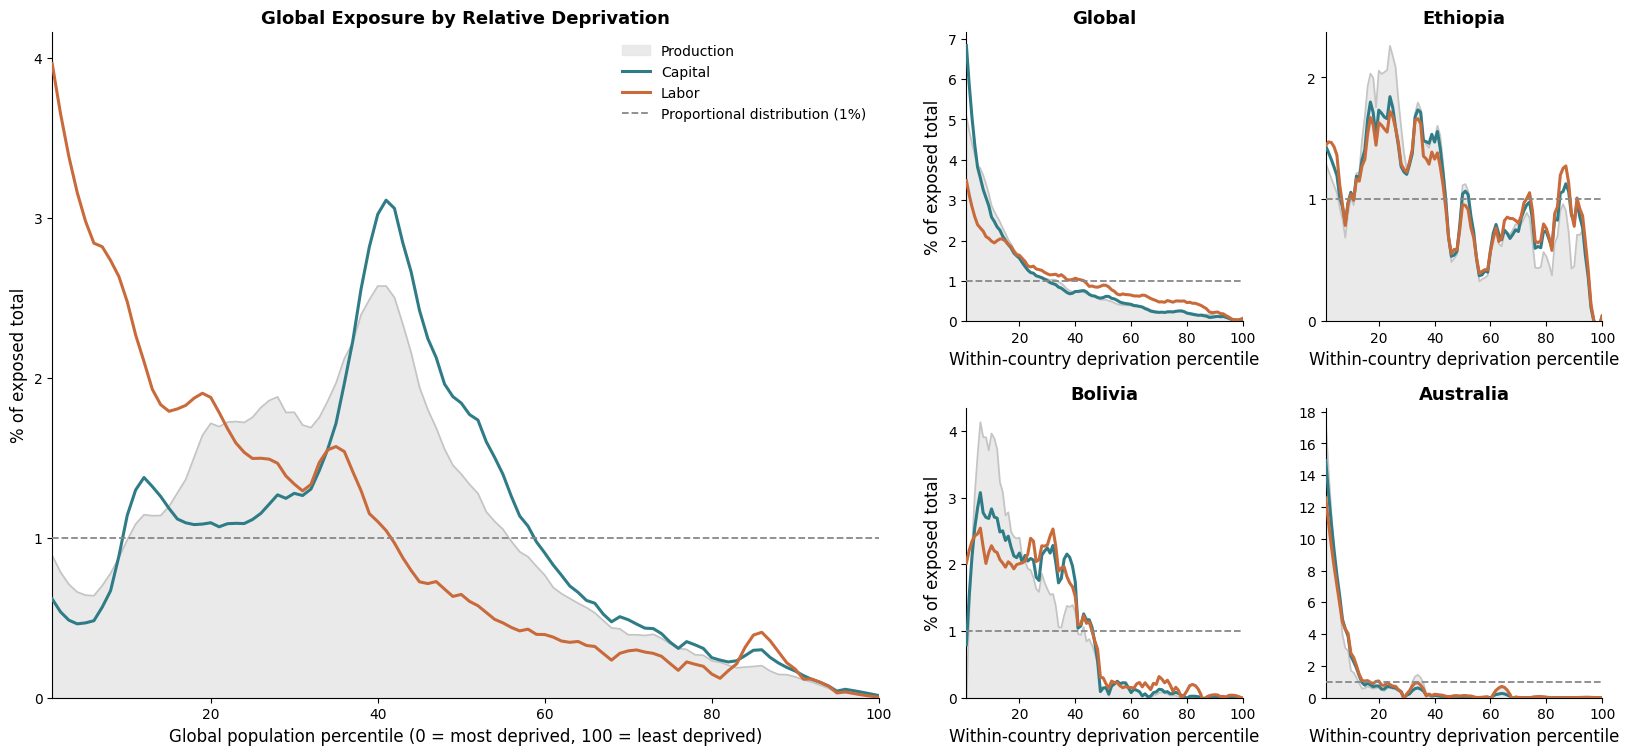

In [11]:
#####  Build figure 

# set countries 
COUNTRIES = ("ETH", "BOL", "AUS")
COUNTRY_NAMES = {"ETH": "Ethiopia", "BOL": "Bolivia", "AUS": "Australia"}

# plot
fig = plt.figure(figsize=(20, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1], wspace=0.12)

# ---- Left: global exposure by global deprivation percentile ----
ax_left = fig.add_subplot(gs[0])
mask_global = build_mask(gid0=None)

draw_exposure_line(
    ax_left,
    rd_global_da,
    mask_global,
    title="Global Exposure by Relative Deprivation",
    xlabel="Global population percentile (0 = most deprived, 100 = least deprived)",
    ylabel="% of exposed total",
    legend=True,
)

# ---- Right: 2x2 grid — national-percentile exposure ----
gs_right = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1], wspace=0.3, hspace=0.3)

panel_specs = [("Global", None)] + [
    (COUNTRY_NAMES.get(c, c), c) for c in COUNTRIES
]

right_axes = [fig.add_subplot(gs_right[i // 2, i % 2]) for i in range(4)]

nat_xlabel = "Within-country deprivation percentile"

for i, (ax, (panel_title, gid0)) in enumerate(zip(right_axes, panel_specs)):
    mask = build_mask(gid0)
    is_left_column = i % 2 == 0
    draw_exposure_line(
        ax,
        rd_national_da,
        mask,
        title=panel_title,
        xlabel=nat_xlabel,
        ylabel="% of exposed total" if is_left_column else None,
        legend=False,
    )

fig.subplots_adjust(top=0.86, bottom=0.12)

plt.savefig(FIG_DIR / "Figure_5_distribution_of_exposure.tiff", dpi=300, bbox_inches="tight")

plt.show()